Micheal Olorunsola

# 

## **Introduction**

One of science’s greatest mysteries, the brain, through millennia of
research, has divulged the mechanics of consciousness via incremental
discoveries that have really only revealed just how much remains hidden;
a Pandora’s box of sorts. Every hard-won discovery peels back a layer of
understanding only to reveal a new, unexplored layer beneath it. Seldom
does a realm feel more tangible for this paradox between discovery and
continued mystery than in the domain of language acquisition— the ease
with which children effortlessly pick up complex grammatical structures,
while adults struggle through the same material in a classroom, has
fascinated researchers for decades. 

Central to this debate is the critical period hypothesis, first formally articulated by Lenneberg (1967), which proposes that there exists a biologically bounded window— closing roughly around puberty— during which language acquisition proceeds naturally and with high ultimate attainment. Beyond this window, the hypothesis holds, full native-like proficiency becomes increasingly difficult to achieve regardless of motivation or instruction. Empirical support for this claim has accumulated over decades: Johnson & Newport (1989) demonstrated in a landmark study that age of arrival in an English-speaking country predicted grammatical proficiency among Chinese and Korean immigrants, with a sharp decline in performance among those who arrived after puberty. More recently, Hartshorne, Tenenbaum & Pinker (2018) leveraged a large-scale online grammar test to revisit this question at unprecedented scale, finding that the critical period for syntax may extend longer than previously thought— but that a decline in acquisition ability is nonetheless real and detectable.

This report draws on data from Hartshorne et al. (2018), a study of over 600,000 second language learners who completed an online English grammar test. Specifically, we investigate three factors that may shape English proficiency: the age at which a person began learning English, whether they speak multiple languages, and whether they self-identify as having a psychiatric disorder. Through exploratory data analysis, inferential testing, and generalized additive modeling, we aim to shed light on these questions and better understand what predicts English proficiency in a diverse, global sample of learners.

---

## **Data Preparation**

Before any analysis, we introduce the variables of interest that will be used throughout this report and state our hypothesis, then conduct a formal audit of the dataset to document its structure, identify anomalies, make principled decisions about how to handle them, and present the resulting cleaned dataset. This section follows a five-step workflow: variable specification, hypothesis, auditing, anomaly resolution, and variable construction.

---

### Variables of Interest

- **Proficiency** (`logit`): logit-transformed proportion of correct responses on the grammar test; serves as the outcome variable
- **Age of Acquisition** (`Eng_start`): self-reported age at which the participant began learning English
- **Current Age** (`age`): participant's age at time of survey
- **Duration** (`duration`): derived variable; years of English exposure, computed as `age − Eng_start`
- **Speaker Category** (`speaker_cat`): categorical classification of the participant as native, early, late, or foreign speaker
- **Multilingual** (`multilingual`): derived binary indicator; TRUE if participant reported more than one primary language
- **Psychiatric** (`psychiatric`): binary indicator for self-reported psychiatric diagnosis; used as an exclusion-relevant covariate

---

### Hypothesis

If the critical period hypothesis holds, then **age of acquisition should be the strongest predictor of English proficiency**, with earlier acquisition associated with higher attainment in a **non-linear** pattern that steepens after a developmental threshold. Multilingual status and psychiatric diagnosis are expected to show weaker and less consistent associations with proficiency.

---

### Data Auditing

We begin by loading the dataset and computing a distribution summary table for the key continuous variables in our analysis: proficiency (`logit`), age of acquisition (`Eng_start`), current age (`age`), and duration of English exposure (`duration`, derived below). Summary statistics include minimum, quartiles, mean, maximum, and skewness. We also apply the **Grubbs test** to each variable to formally assess whether the most extreme observation constitutes a statistical outlier.

In [ ]:
# Install required packages (run once)
install.packages(c(
  "tidyverse",
  "stringr", 
  "outliers",
  "psych",
  "gridExtra",
  "grid",
  "effectsize",
  "boot",
  "mgcv",
  "ggcorrplot"
))

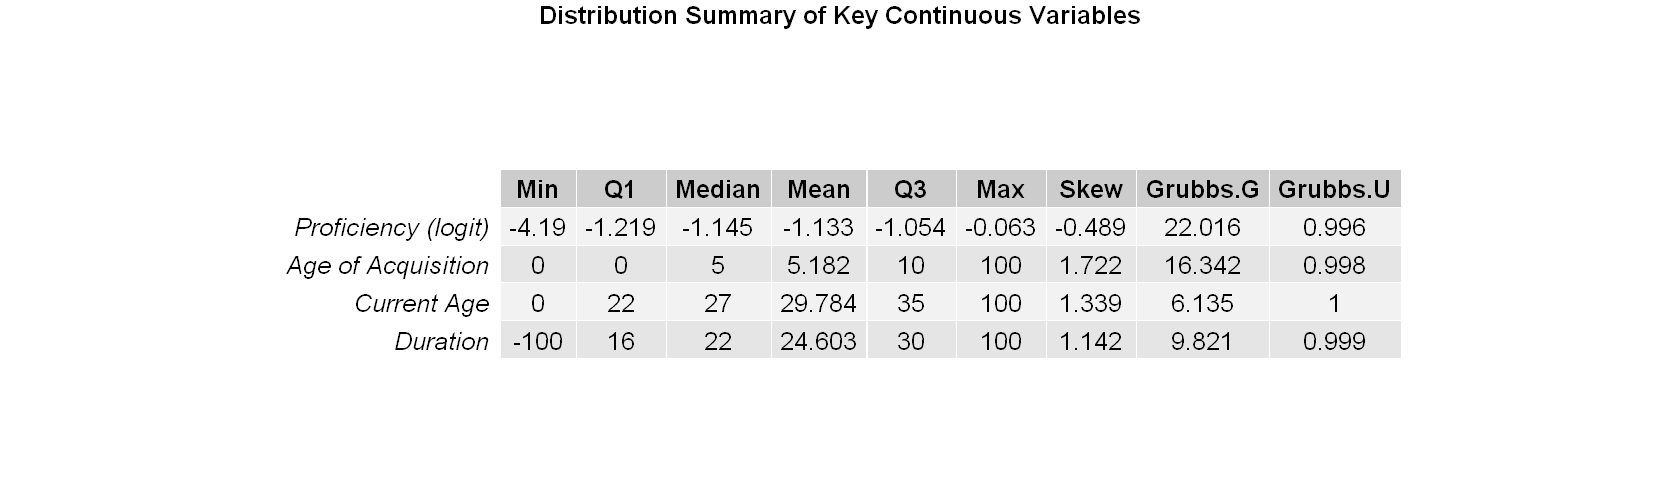

In [30]:
library(tidyverse)
library(stringr)
library(outliers)
library(psych)
library(gridExtra)
library(grid)

lang.df <- read.csv("https://raw.githubusercontent.com/fhorner/85309/main/finalProj/finalProjSmall.csv")

# Duration construction
lang.df$duration <- lang.df$age - lang.df$Eng_start

# Summary statistics
audit_vars <- list(
  logit     = lang.df$logit,
  Eng_start = lang.df$Eng_start,
  age       = lang.df$age,
  duration  = lang.df$duration
)

# Build distribution table (min, Q1, median, mean, Q3, max)
dist_table <- round(t(do.call(cbind, lapply(audit_vars, summary))), digits = 3)

# Append skewness
skew_vals <- sapply(audit_vars, skew)
dist_table <- round(cbind(dist_table, Skew = skew_vals), digits = 3)

# Grubbs test: extract G and U statistics for each variable
grubbs_G <- sapply(audit_vars, function(x) round(grubbs.test(x)$statistic["G"], 3))
grubbs_U <- sapply(audit_vars, function(x) round(grubbs.test(x)$statistic["U"], 3))

dist_table <- cbind(dist_table, `Grubbs G` = grubbs_G, `Grubbs U` = grubbs_U)

# Clean up row/column names for display
colnames(dist_table) <- c("Min", "Q1", "Median", "Mean", "Q3", "Max", "Skew", "Grubbs G", "Grubbs U")
rownames(dist_table) <- c("Proficiency (logit)", "Age of Acquisition", "Current Age", "Duration")

# Display as formatted table
options(repr.plot.width = 14, repr.plot.height = 4)

mytheme <- ttheme_default(base_size = 15, base_colour = "black")
grid.newpage()

pushViewport(viewport(x = 0.5, y = 0.45, width = 0.98, height = 0.75))
grid.table(data.frame(dist_table), theme = mytheme)
popViewport()

grid.draw(textGrob("Distribution Summary of Key Continuous Variables",
                   gp = gpar(fontsize = 15, fontface = "bold"),
                   x = unit(0.5, "npc"), y = unit(0.97, "npc")))

The distribution of `logit`-transformed proficiency is approximately symmetric (skew ≈ 0), confirming the transformation's suitability for our parametric tests. `Eng_start` is heavily right-skewed (skew > 1), reflecting the large proportion of native or near-native speakers who began acquiring English at or near birth. `Duration` shows a mild negative skew. The Grubbs test identifies at least one statistical outlier in each variable. Examination of the extremes reveals that values such as `Eng_start` = 100 and `age` = 100, while internally consistent, are implausible as genuine observations and likely reflect data entry artifacts. Accordingly, three exclusion criteria are applied prior to analysis: participants where `Eng_start` > `age` (logically impossible acquisition timelines), participants where `age` > 75 (sparse and implausible for an online testing context), and participants where `Eng_start` > 60  (far outside the realistic range of second language acquisition onset, and the region where most impossible age anomalies cluster). These exclusions are implemented in the anomaly resolution step below.

---

### Anomaly Identification and Resolution

A critical data integrity issue arises from the self-reported nature of `Eng_start` and `age`: for some participants, `Eng_start` exceeds `age`, which is logically impossible (one cannot have started learning a language at an age older than their current age). We identify and document these cases programmatically:

In [9]:
# Identify impossible cases
impossible <- lang.df |>
  filter(Eng_start > age)

n_impossible <- nrow(impossible)
pct_impossible <- round(100 * n_impossible / nrow(lang.df), 2)

cat(sprintf("Cases where Eng_start > age: %d (%.2f%% of sample)\n",
            n_impossible, pct_impossible))
cat(sprintf("Eng_start range in anomalous cases: %.0f – %.0f\n",
            min(impossible$Eng_start), max(impossible$Eng_start)))
cat(sprintf("Age range in anomalous cases: %.0f – %.0f\n",
            min(impossible$age), max(impossible$age)))
cat(sprintf(
  "These %d cases (%.2f%% of the full sample) represent clear data entry errors.
They are excluded because they produce negative, uninterpretable duration values
and would introduce systematic noise into acquisition-age analyses.\n",
  n_impossible, pct_impossible
))

Cases where Eng_start > age: 174 (0.13% of sample)
Eng_start range in anomalous cases: 1 – 100
Age range in anomalous cases: 0 – 63
These 174 cases (0.13% of the full sample) represent clear data entry errors.
They are excluded because they produce negative, uninterpretable duration values
and would introduce systematic noise into acquisition-age analyses.


In [10]:
# Remove logically impossible cases
lang.df <- lang.df |>
  filter(Eng_start <= age,
         age < 75,
         Eng_start < 60)

cat(sprintf("Remaining observations after exclusion: %d\n", nrow(lang.df)))

Remaining observations after exclusion: 135607


---

### Variable Construction

With anomalies resolved, we construct the two derived variables used throughout this report. First, the `multilingual` factor variable (whether a participant listed more than one primary language):

In [11]:
lang.df$multilingual <- as.factor(str_detect(lang.df$primelangs, ","))

Second, the `duration` variable is already computed above, but we retain and validate it:

In [12]:
# Confirm no negative durations remain after anomaly exclusion
neg_dur <- sum(lang.df$duration < 0, na.rm = TRUE)
cat(sprintf("Negative duration values after exclusion: %d\n", neg_dur))

Negative duration values after exclusion: 0


The dataset is now clean, anomalies are documented, and all derived variables are
constructed. Raw and processed forms are carried forward into the analyses below.

### Resulting Cleaned Dataset:

In [13]:
head(lang.df[, c("logit", "Eng_start", "age", "duration", "speaker_cat", "multilingual", "psychiatric")])

,logit,Eng_start,age,duration,speaker_cat,multilingual,psychiatric
,<dbl>,<int>,<int>,<int>,<chr>,<fct>,<int>
1,-1.145132,10,41,31,late,FALSE,0
2,-1.193922,9,22,13,late,FALSE,0
3,-1.169230,6,19,13,foreign,FALSE,0
4,-1.011601,6,32,26,foreign,TRUE,0
5,-1.054161,0,26,26,native,FALSE,0
6,-1.271884,9,42,33,late,FALSE,0


## **Exploratory Data Analysis**

Before conducting formal inference, we visually explore the structure of the data to assess distributional patterns, surface potential group differences, and identify associations among predictors. Specifically, we will be examining the distributions of:

+ Proficiency (`logit`) across speaker categories (native, late, foreign)
+ Proficiency by multilingual status (`multilingual`)
+ Proficiency by psychiatric status (`psychiatric`)
+ Proficiency against age of acquisition (`Eng_start`) and duration of exposure (`duration`)
+ Collinearity among continuous predictors via a correlation matrix heatmap

---

### 1. Proficiency by Speaker Category

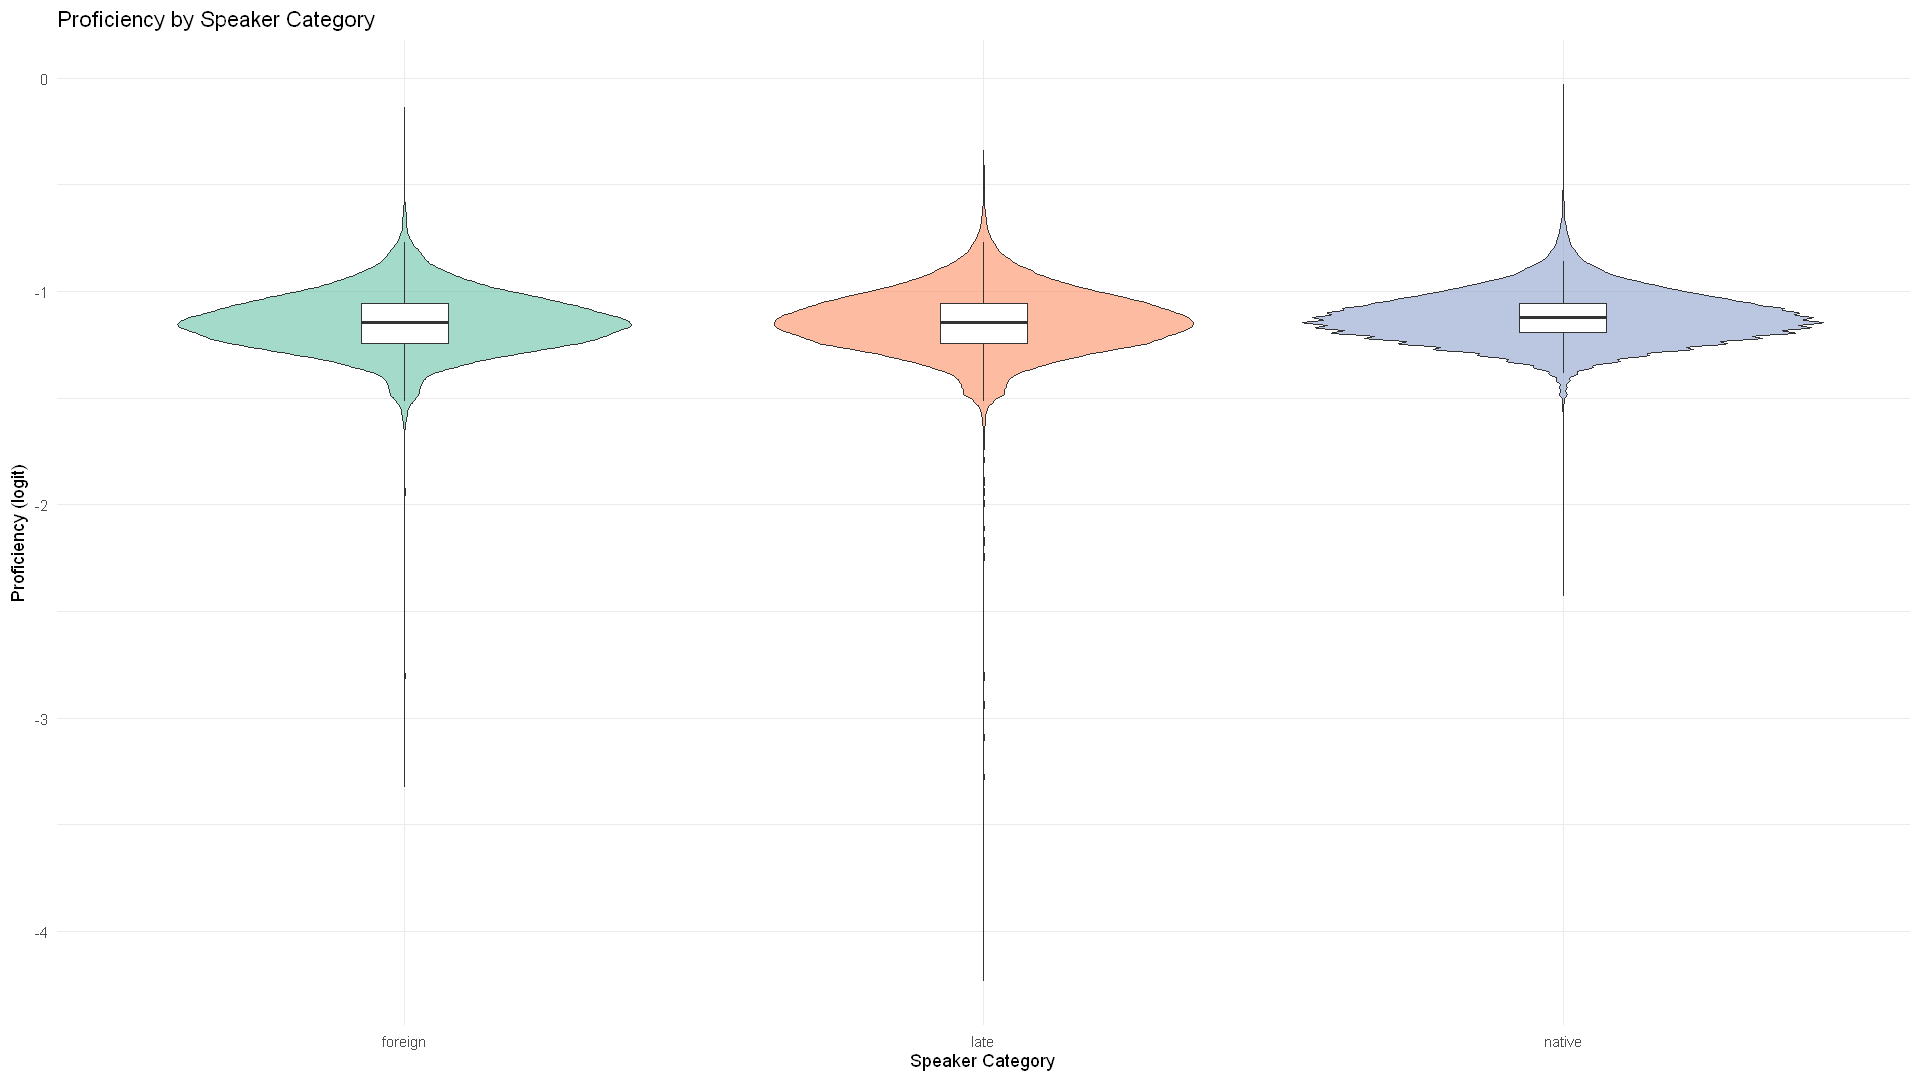

In [30]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(lang.df, aes(x = speaker_cat, y = logit, fill = speaker_cat)) +
  geom_violin(alpha = 0.6, trim = FALSE) +
  geom_boxplot(width = 0.15, fill = "white", outlier.shape = NA) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = "Proficiency by Speaker Category",
    x = "Speaker Category",
    y = "Proficiency (logit)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

*Native* speakers show the highest median proficiency, followed by *late* and *foreign* speakers — consistent with the critical period hypothesis. The distributions are relatively tight for native speakers and widen progressively for later acquisition groups, suggesting increasing variability in outcomes as acquisition age increases. This pattern motivates the **ANOVA** conducted in the inference section.

---

### 2. Proficiency by Multilingual Status

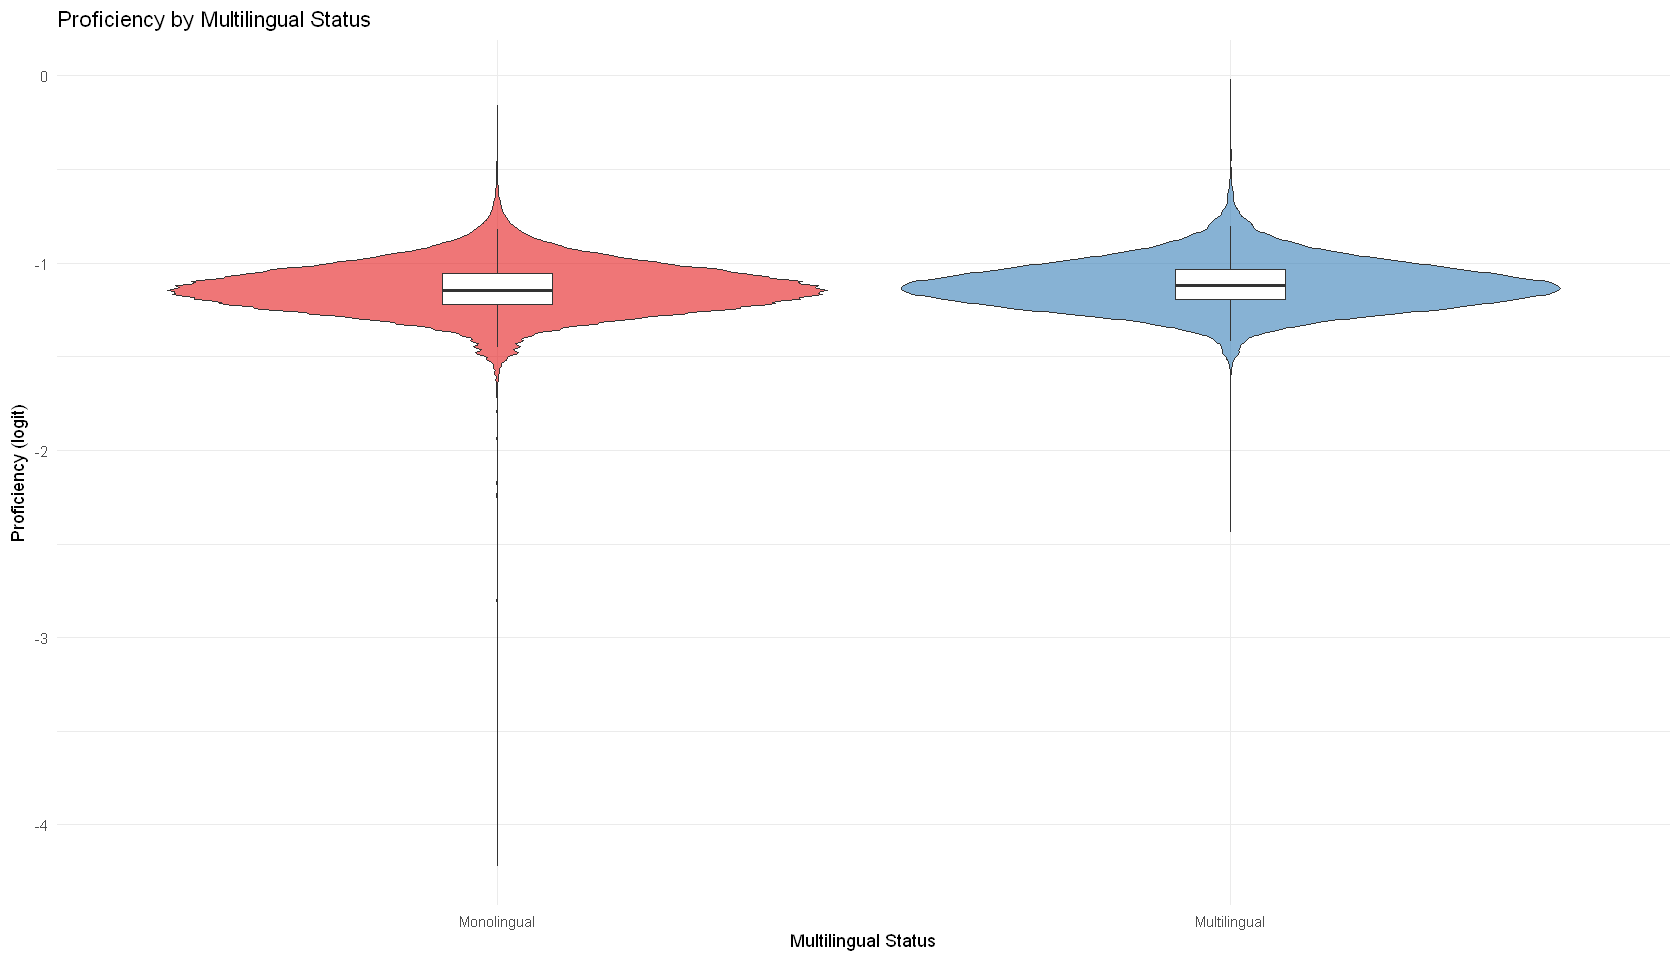

In [10]:
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(lang.df |> filter(!is.na(multilingual)),
       aes(x = multilingual, y = logit, fill = multilingual)) +
  geom_violin(alpha = 0.6, trim = FALSE) +
  geom_boxplot(width = 0.15, fill = "white", outlier.shape = NA) +
  scale_fill_brewer(palette = "Set1") +
  scale_x_discrete(labels = c("FALSE" = "Monolingual", "TRUE" = "Multilingual")) +
  labs(
    title = "Proficiency by Multilingual Status",
    x = "Multilingual Status",
    y = "Proficiency (logit)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

Multilingual participants show a *modestly* higher median proficiency than monolinguals, though the distributions overlap substantially. The difference is visually small, suggesting that any inferential effect — while potentially statistically significant given the large sample — may be limited in practical magnitude. This is examined formally via **t-test** in the inference section.

---

### 3. Proficiency by Psychiatric Status

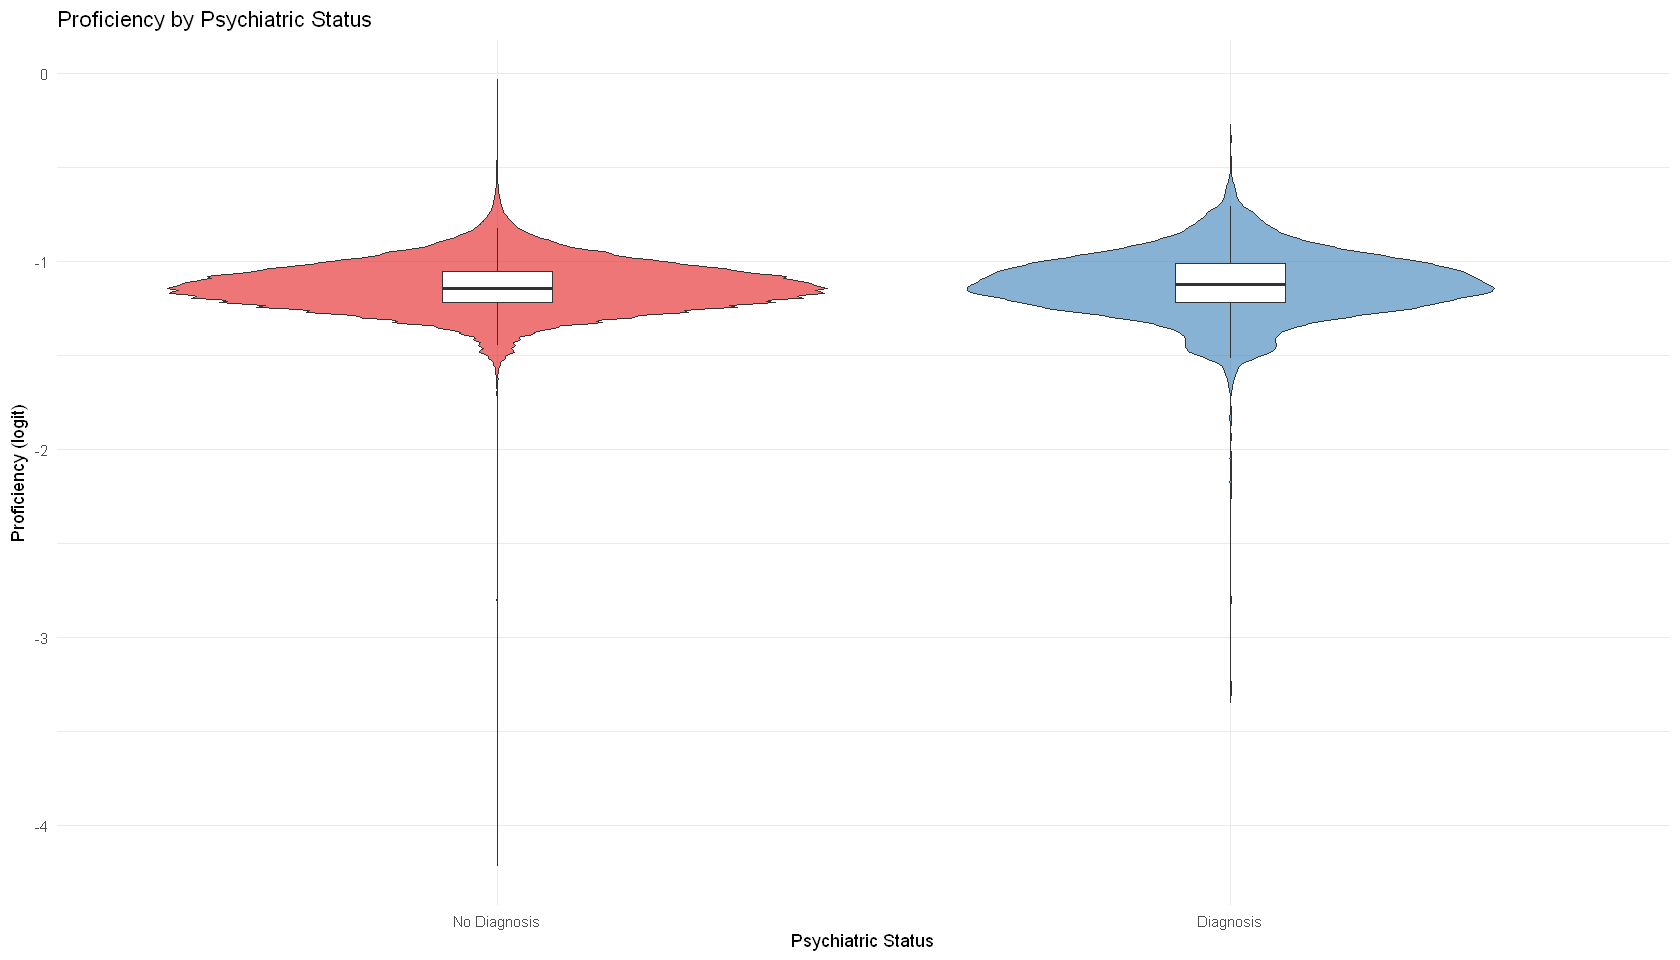

In [11]:
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(lang.df, aes(x = as.factor(psychiatric), y = logit, fill = as.factor(psychiatric))) +
  geom_violin(alpha = 0.6, trim = FALSE) +
  geom_boxplot(width = 0.15, fill = "white", outlier.shape = NA) +
  scale_fill_brewer(palette = "Set1") +
  scale_x_discrete(labels = c("0" = "No Diagnosis", "1" = "Diagnosis")) +
  labs(
    title = "Proficiency by Psychiatric Status",
    x = "Psychiatric Status",
    y = "Proficiency (logit)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


The distributions for participants with and without a self-reported psychiatric diagnosis are **nearly identical**. Any observed difference is likely negligible in effect size, and as noted in the introduction, a statistically significant result here would more plausibly reflect **selection bias than a genuine cognitive relationship**. This is examined in the inference section.

---

### 4. Proficiency vs. Age of Acquisition and Duration

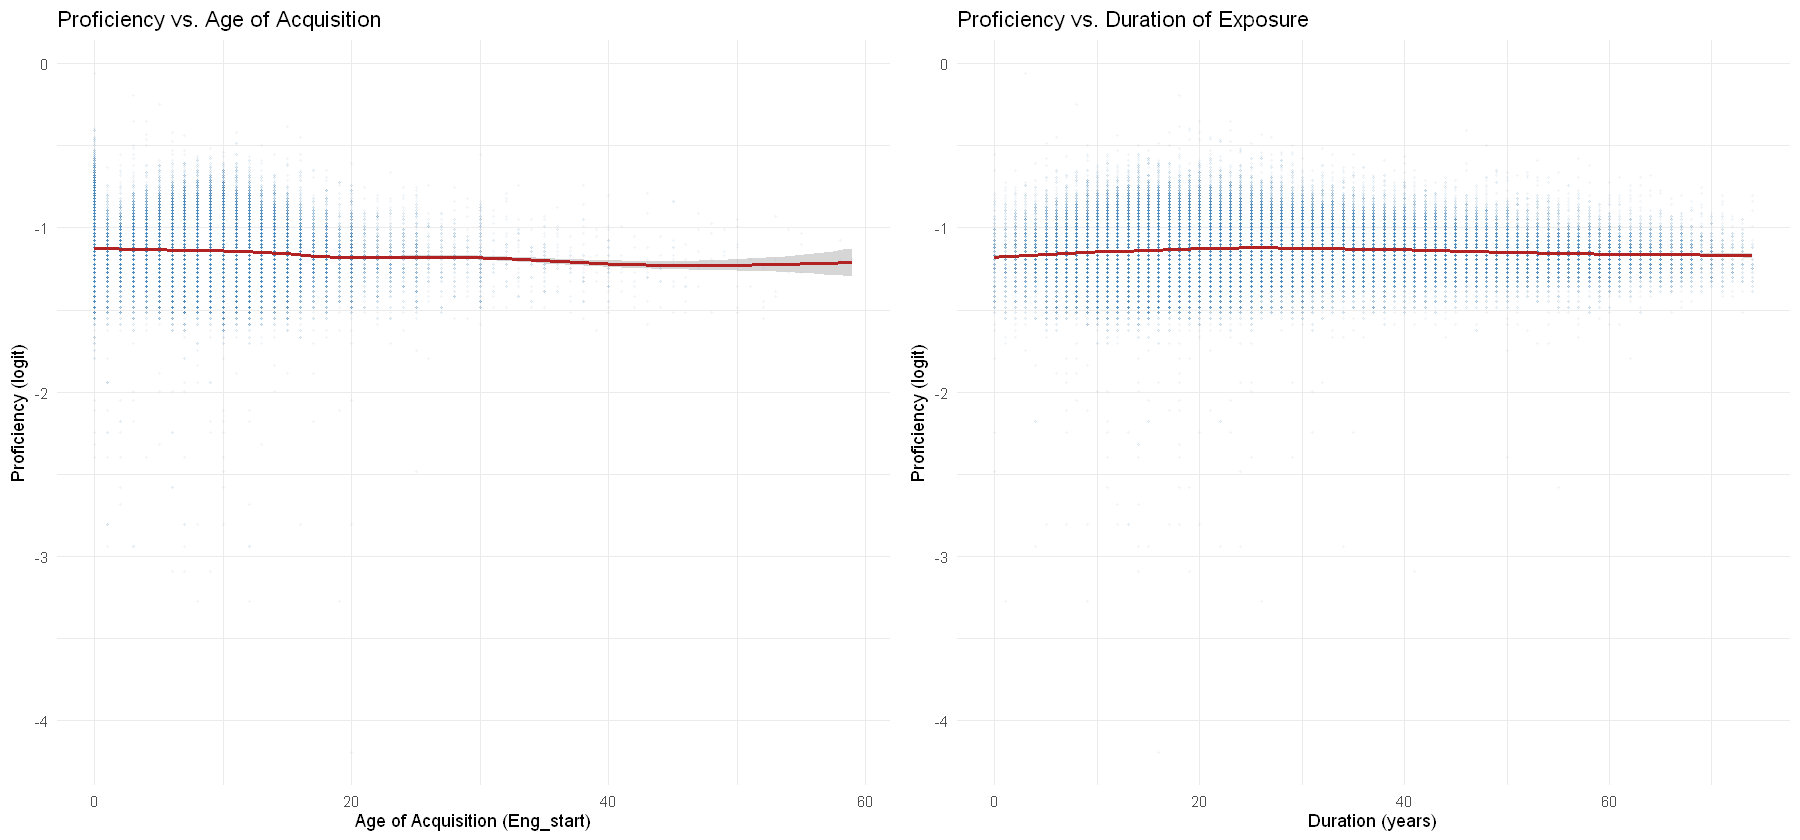

In [22]:
library(mgcv)
options(repr.plot.width = 15, repr.plot.height = 7, warn = -1)

suppressMessages({
    p1 <- ggplot(lang.df, aes(x = Eng_start, y = logit)) +
      geom_point(alpha = 0.05, size = 0.5, color = "steelblue") +
      geom_smooth(method = "gam", color = "firebrick", se = TRUE) +
      labs(
        title = "Proficiency vs. Age of Acquisition",
        x = "Age of Acquisition (Eng_start)",
        y = "Proficiency (logit)"
      ) +
      theme_minimal()

    p2 <- ggplot(lang.df, aes(x = duration, y = logit)) +
      geom_point(alpha = 0.05, size = 0.5, color = "steelblue") +
      geom_smooth(method = "gam", color = "firebrick", se = TRUE) +
      labs(
        title = "Proficiency vs. Duration of Exposure",
        x = "Duration (years)",
        y = "Proficiency (logit)"
      ) +
      theme_minimal()

    gridExtra::grid.arrange(p1, p2, ncol = 2)
})


Both plots reveal non-linear relationships. Proficiency modestly declines as age of acquisition increases, with a steep drop in the earlier years that gradually levels off— consistent with a critical period effect rather than a purely linear acquisition-age penalty. The relationship with `duration` is noisier, with diminishing returns at longer exposures. The presence of non-linearity here directly informs our modeling strategy: rather than assuming a linear acquisition-age relationship, we fit generalized additive models with spline terms in the modeling section, allowing the data to determine the functional form of the relationship.

---

### 5. Correlation Matrix Heatmap

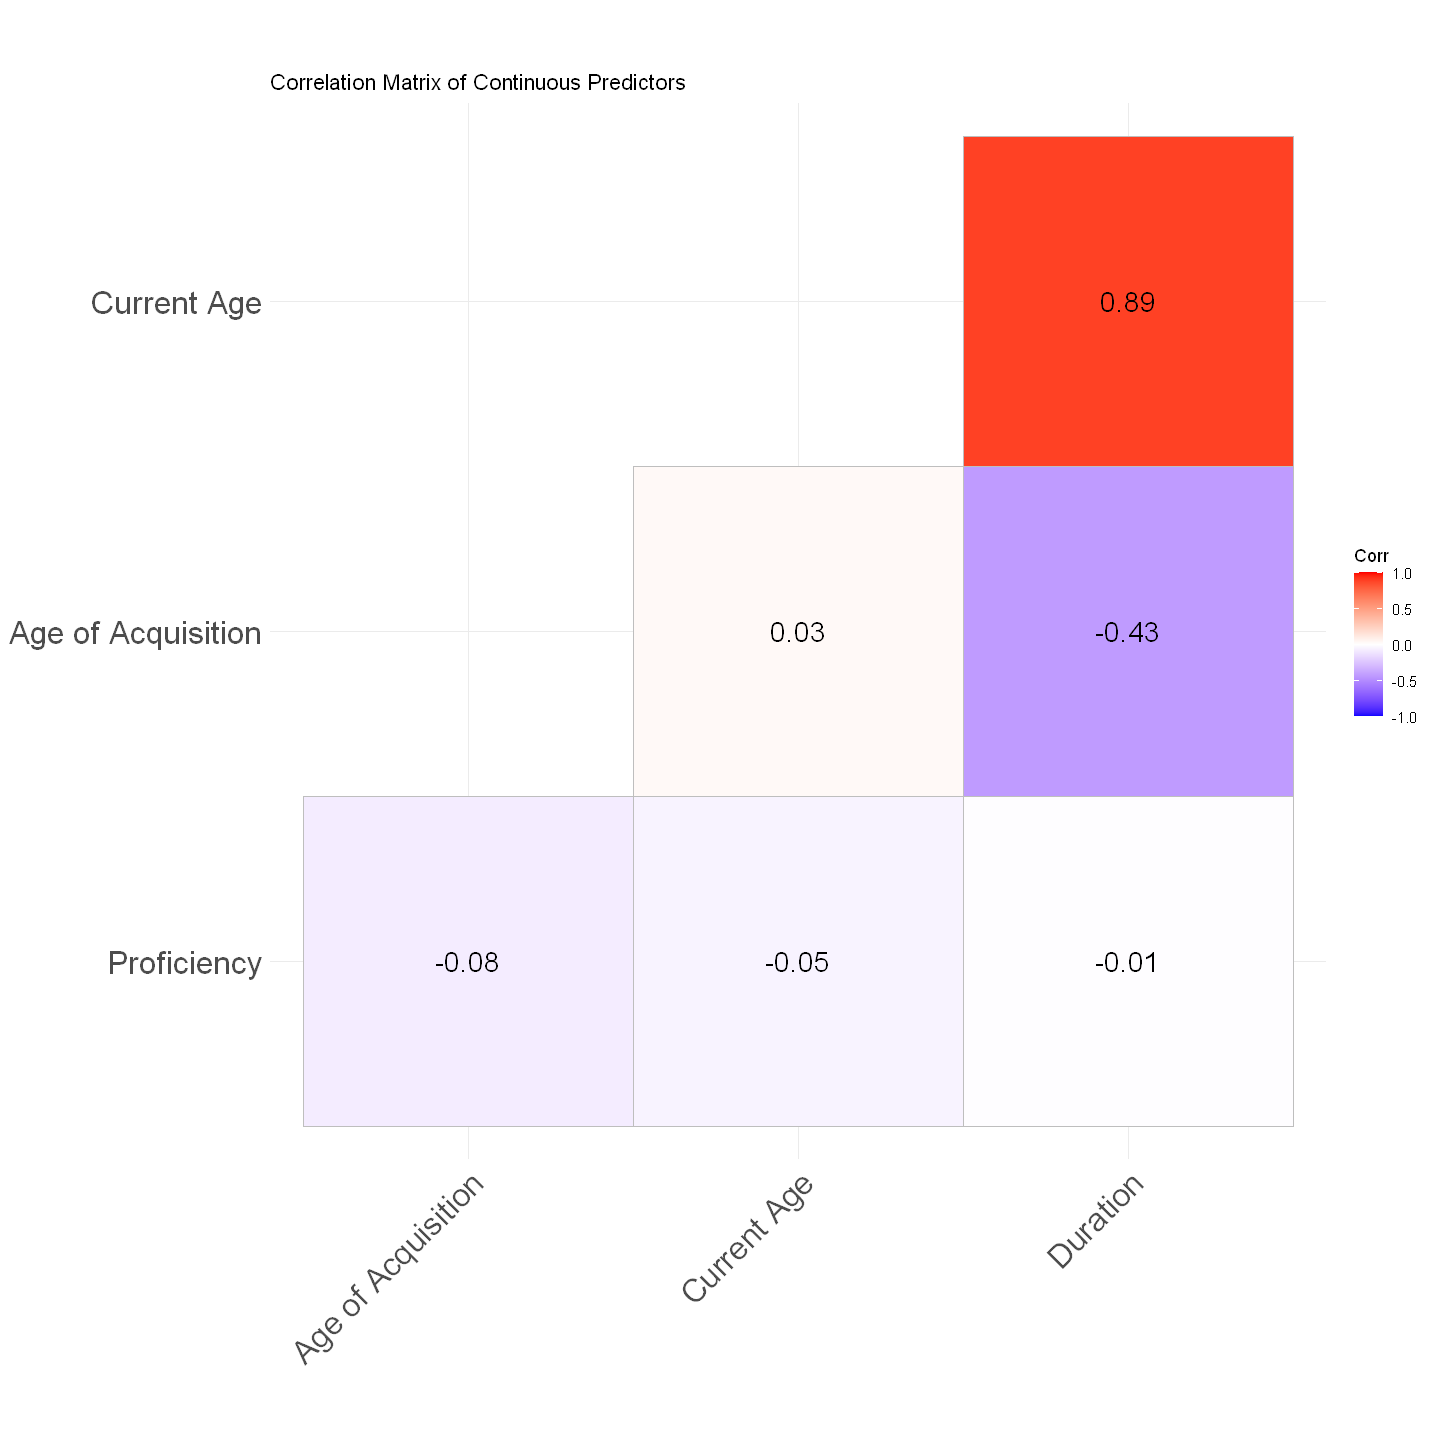

In [18]:

library(ggcorrplot)

options(repr.plot.width = 12, repr.plot.height = 12)

cor_vars <- lang.df |>
  select(logit, Eng_start, age, duration) |>
  rename(
    "Proficiency" = logit,
    "Age of Acquisition" = Eng_start,
    "Current Age" = age,
    "Duration" = duration
  )

cor_matrix <- round(cor(cor_vars, use = "complete.obs"), 2)

ggcorrplot(cor_matrix,
           method = "square",
           type = "lower",
           lab = TRUE,
           lab_size = 6,
           colors = c("blue", "white", "red"),
           title = "Correlation Matrix of Continuous Predictors",
           tl.cex = 19,
           ggtheme = theme_minimal())


The heatmap reveals the collinearity structure anticipated in the data preparation section. `Duration` and `age` are strongly positively correlated, while `Eng_start` and `duration` are negatively correlated — both expected, given that `duration = age − Eng_start`. This near-linear dependency means these three variables cannot be entered together into a regression model without introducing severe multicollinearity, which directly informs the model specification strategy in the modeling section.

---

## **Inference**

Having explored  the data visually, we now formally test the group differences surfaced in the EDA. We apply three inferential tests, followed by bootstrapping to validate the stability of significant findings.

Specifically, we test:

+ Whether multilingual status is associated with differences in English proficiency (Welch two-sample t-test)
+ Whether psychiatric status is associated with differences in English proficiency (Welch two-sample t-test)
+ Whether proficiency differs significantly across speaker categories (one-way ANOVA with post-hoc testing)

Bootstrapping is then applied to the significant effects to confirm that findings are not dependent on distributional assumptions

---

### 1. Proficiency by Multilingual Status (t-test)

In [15]:
multilingual_test <- t.test(logit ~ multilingual, data = lang.df, var.equal = FALSE)
multilingual_test


	Welch Two Sample t-test

data:  logit by multilingual
t = -19.404, df = 37052, p-value < 2.2e-16
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -0.02024249 -0.01652820
sample estimates:
mean in group FALSE  mean in group TRUE 
          -1.136248           -1.117863 


In [17]:
library(effectsize)

cohen_multi <- cohens_d(logit ~ multilingual, data = lang.df)
cohen_multi

Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.1327812,0.95,-0.1466685,-0.1188933



The Welch two-sample t-test yields a statistically significant difference in proficiency between multilingual and monolingual participants (`p < 0.001`). However, the effect size is negligible (Cohen's `d = -0.133`), and the direction is noteworthy: multilinguals score slightly lower than monolinguals on average. Given the sample size exceeding 130,000, **statistical significance here carries little practical weight**— the confidence interval excludes zero, but the difference itself is trivially small.

---

### 2. Proficiency by Psychiatric Status (t-test)

In [15]:
psych_test <- t.test(logit ~ psychiatric, data = lang.df, var.equal = FALSE)
psych_test


	Welch Two Sample t-test

data:  logit by psychiatric
t = -2.621, df = 4421.2, p-value = 0.008796
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.01277430 -0.00184174
sample estimates:
mean in group 0 mean in group 1 
      -1.133184       -1.125876 


In [16]:
cohen_psych <- cohens_d(logit ~ psychiatric, data = lang.df)
cohen_psych

Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.05271335,0.95,-0.08322268,-0.02220382


The Welch two-sample t-test yields a statistically significant result (`p = 0.009`), with participants reporting a psychiatric diagnosis scoring marginally higher than those without (-1.126 vs. -1.133). However, Cohen's `d = -0.053` is essentially zero — this is a trivially small effect by any conventional standard. The confidence interval (-0.083, -0.022) excludes zero, but again this reflects the test's sensitivity at large N rather than any meaningful difference. Selection bias remains the most plausible explanation: individuals with psychiatric diagnoses may systematically differ in education, language exposure, or test-taking behavior in ways the data cannot account for.

---

### 3. Proficiency by Speaker Category (ANOVA)

In [25]:
anova_model <- aov(logit ~ speaker_cat, data = lang.df)
summary(anova_model)

                Df Sum Sq Mean Sq F value Pr(>F)    
speaker_cat      2   14.7   7.362   384.1 <2e-16 ***
Residuals   136063 2607.8   0.019                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [26]:
tukey_result <- TukeyHSD(anova_model)
tukey_result


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = logit ~ speaker_cat, data = lang.df)

$speaker_cat
                      diff         lwr         upr p adj
late-foreign   0.006460278 0.003730148 0.009190409 1e-07
native-foreign 0.025350996 0.022644167 0.028057826 0e+00
native-late    0.018890718 0.016994323 0.020787112 0e+00


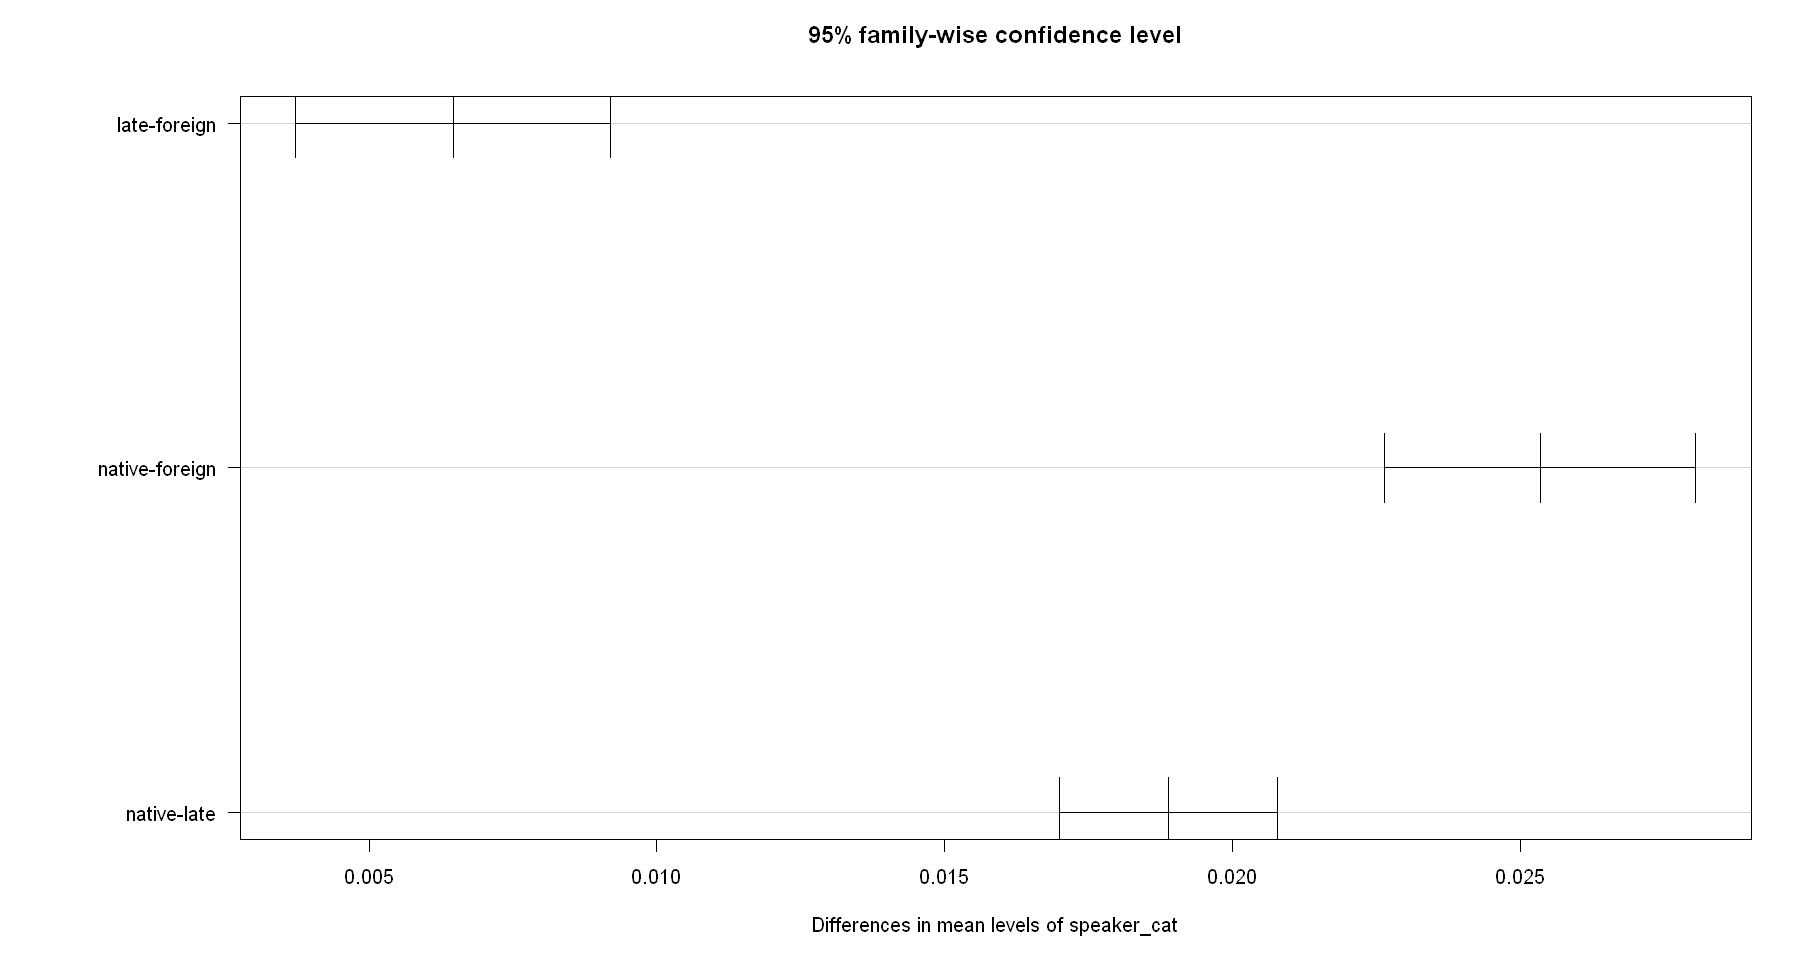

In [28]:
options(repr.plot.width = 15, repr.plot.height = 8)
par(mar = c(5, 10, 4, 2))
plot(tukey_result, las = 1)


The one-way ANOVA reveals a highly significant effect of speaker category on proficiency (`F(2, 135604) = 385.2, p < 0.001`). Tukey's HSD post-hoc tests confirm that all three pairwise comparisons are significant: native vs. foreign (`diff = 0.025, p < 0.001`), native vs. late (`diff = 0.019, p < 0.001`), and late vs. foreign (`diff = 0.007, p < 0.001`). Native speakers show the highest proficiency, followed by late speakers, then foreign speakers— consistent with the ordering observed in the EDA violin plots and with the critical period hypothesis more broadly.

That said, the absolute mean differences are small. The largest gap (between native and foreign speakers) is only 0.025 logit units, and the smallest (between late and foreign) is 0.007. Given that the residual mean square is 0.019, **these differences, while statistically unambiguous, are modest in practical terms**. The F-statistic of 385.2 is largely a product of the sample size rather than evidence of large group separation. The Tukey plot corroborates this: all confidence intervals are narrow and positive, confirming directionality, but centered on small values throughout.

---

### 4. Bootstrapping

We bootstrap the two t-test mean differences to confirm that the significant effects from above are stable and not dependent on normality assumptions. We use 10,000 resamples:

In [20]:
library(boot)

# Multilingual bootstrap
boot_multi <- boot(
  data = lang.df |> filter(!is.na(multilingual)),
  statistic = function(d, i) {
    d_boot <- d[i, ]
    mean(d_boot$logit[d_boot$multilingual == TRUE], na.rm = TRUE) -
    mean(d_boot$logit[d_boot$multilingual == FALSE], na.rm = TRUE)
  },
  R = 10000
)

boot.ci(boot_multi, type = "perc")

# Psychiatric bootstrap
boot_psych <- boot(
  data = lang.df,
  statistic = function(d, i) {
    d_boot <- d[i, ]
    mean(d_boot$logit[d_boot$psychiatric == 1], na.rm = TRUE) -
    mean(d_boot$logit[d_boot$psychiatric == 0], na.rm = TRUE)
  },
  R = 10000
)

boot.ci(boot_psych, type = "perc")

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 10000 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_multi, type = "perc")

Intervals : 
Level     Percentile     
95%   ( 0.0165,  0.0202 )  
Calculations and Intervals on Original Scale

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 10000 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_psych, type = "perc")

Intervals : 
Level     Percentile     
95%   ( 0.0017,  0.0128 )  
Calculations and Intervals on Original Scale


The bootstrapped 95% confidence intervals based on 10,000 resamples corroborate both t-test findings. The bootstrapped CI for the multilingual mean difference is (0.0165, 0.0202), and for psychiatric status (0.0017, 0.0128)— both exclude zero, confirming that the effects are stable and not an artifact of distributional assumptions.

However, in observing that 1) the multilingual difference is bounded between roughly 0.016 and 0.020 logit units, and 2) the psychiatric difference between 0.002 and 0.013, we acknowledge that both intervals have extremely narrow ranges centered on small values. The bootstrapping does not rescue the practical significance of either effect; it simply confirms that the negligible differences observed in the t-tests are reliably negligible. In a dataset of this size, a stable near-zero effect is still a near-zero effect.

---

## **Modeling**

Having established significant but practically small group differences in the inference section, we now move to modeling the relationship between our predictors and English proficiency. Given the non-linear relationships surfaced in the EDA— particularly the steep, leveling-off curve between `Eng_start` and `logit` — we fit Generalized Additive Models (GAMs) with spline terms rather than assuming a linear functional form. We fit two models and compare their out-of-sample performance via k-fold cross-validation. After the fact, we then bootstrap the spline term from the best model to confirm the stability of the non-linear fit:

+ **Model 1 (Base GAM)**: spline on `Eng_start` only
+ **Model 2 (Extended GAM)**: spline on `Eng_start` + parametric terms for `multilingual` and `psychiatric`
+ **Model Comparison**: 10-fold cross-validation on both models
+ **Bootstrapping**: stability validation of the `Eng_start` spline term

---

### 1. Base GAM: Spline on Age of Acquisition

In [19]:
gam1 <- gam(logit ~ s(Eng_start), data = lang.df, method = "REML")
summary(gam1)


Family: gaussian 
Link function: identity 

Formula:
logit ~ s(Eng_start)

Parametric coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.1329541  0.0003751   -3021   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
               edf Ref.df     F p-value    
s(Eng_start) 7.105  7.807 133.4  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.00763   Deviance explained = 0.768%
-REML = -76015  Scale est. = 0.019075  n = 135607

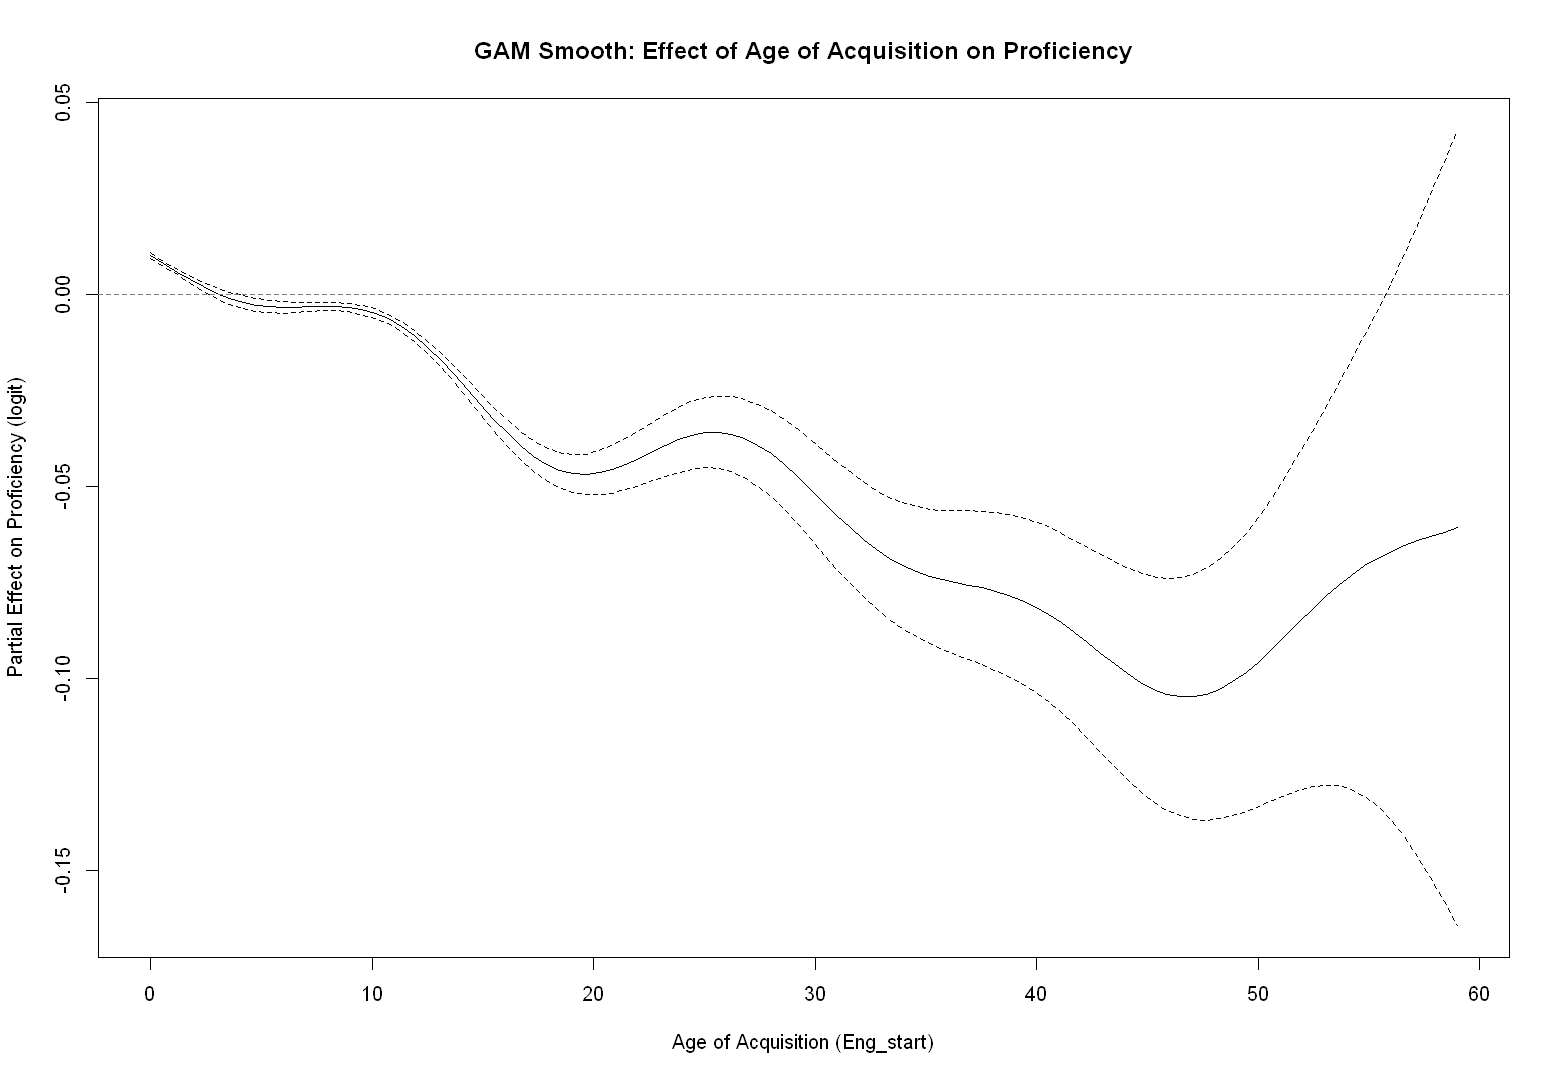

In [29]:
options(repr.plot.width = 13, repr.plot.height = 9, warn = -1)
plot(gam1, residuals = FALSE, shade = TRUE, shade.col = "lightblue",
     xlab = "Age of Acquisition (Eng_start)",
     ylab = "Partial Effect on Proficiency (logit)",
     main = "GAM Smooth: Effect of Age of Acquisition on Proficiency")
abline(h = 0, lty = 2, col = "gray50")


The GAM smooth reveals a clear non-linear relationship between age of acquisition and English proficiency. From birth to approximately age 10, proficiency remains relatively stable and near zero partial effect — reflecting that native and very early learners perform similarly regardless of exactly when in early childhood they began. Around age 10, a sustained negative trend emerges: proficiency declines progressively as acquisition age increases through the teens and into adulthood, with the steepest drop occurring between roughly ages 20 and 50. Beyond age 50, the confidence band widens considerably, reflecting sparse data at the upper end of the acquisition age range and warranting caution in interpretation there.

This plot is the **clearest visual evidence in the report for a critical period effect**: it is not simply that later learners have had less time to practice, but that acquisition age itself carries a non-linear penalty on ultimate proficiency attainment.

---

### 2. Extended GAM: Adding Multilingual and Psychiatric Status

In [35]:
gam2 <- gam(logit ~ s(Eng_start) + multilingual + psychiatric,
            data = lang.df |> filter(!is.na(multilingual)),
            method = "REML")
summary(gam2)


Family: gaussian 
Link function: identity 

Formula:
logit ~ s(Eng_start) + multilingual + psychiatric

Parametric coefficients:
                   Estimate Std. Error   t value Pr(>|t|)    
(Intercept)      -1.1371869  0.0004206 -2703.631   <2e-16 ***
multilingualTRUE  0.0221398  0.0009973    22.200   <2e-16 ***
psychiatric       0.0084664  0.0021464     3.944    8e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
               edf Ref.df     F p-value    
s(Eng_start) 7.309  7.985 148.6  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.0113   Deviance explained = 1.14%
-REML = -76257  Scale est. = 0.019004  n = 135607

The extended GAM adds `multilingual` and `psychiatric` as parametric terms alongside the `Eng_start` spline. Both are statistically significant: `multilingual` status ($\beta$ = 0.022, t = 22.200, p < 0.001) and `psychiatric` status (β = 0.008, t = 3.944, p < 0.001). However, the model's explanatory power is strikingly **limited**, with an adjusted $R^2$ = 0.0113, meaning the **model explains just ~1.14% of the variance in proficiency**.

The `Eng_start` spline remains highly significant (edf = 7.309, F = 148.6, p < 0.001), and its edf is consistent with Model 1, confirming that the non-linear acquisition-age relationship is stable regardless of whether the other predictors are included. The parametric coefficients for `multilingual` and `psychiatric` *are* positive— both groups score marginally higher than their counterparts— but the magnitudes (0.022 and 0.008 respectively) are negligible in substantive terms, consistent with the effect sizes observed in the inference section. **Statistical significance here is, again, a function of sample size, not practical importance.**

---

### 3. Model Comparisons: K-Fold Cross-Validation

We use 10-fold cross-validation to compare out-of-sample predictive performance between the two models. Mean squared error (MSE) is our comparison metric:

In [46]:
library(mgcv)

set.seed(42)

# Complete cases only for fair comparison
model_data <- lang.df |>
  filter(!is.na(multilingual))

# Create fold assignments
k <- 10
fold_ids <- sample(rep(1:k, length.out = nrow(model_data)))

# Storage
mse_gam1 <- numeric(k)
mse_gam2 <- numeric(k)

for (i in 1:k) {
  train_data <- model_data[fold_ids != i, ]
  test_data  <- model_data[fold_ids == i, ]
  
  # Fit both models on training fold
  fit1 <- mgcv::gam(logit ~ s(Eng_start), data = train_data, method = "REML")
  fit2 <- mgcv::gam(logit ~ s(Eng_start) + multilingual + psychiatric,
                    data = train_data, method = "REML")
  
  # Predict on test fold
  pred1 <- predict(fit1, newdata = test_data)
  pred2 <- predict(fit2, newdata = test_data)
  
  # Compute MSE
  mse_gam1[i] <- mean((test_data$logit - pred1)^2)
  mse_gam2[i] <- mean((test_data$logit - pred2)^2)
}

results <- data.frame(
  Model = c("Base GAM (Eng_start only)", 
            "Extended GAM (+ multilingual + psychiatric)"),
  Mean_MSE = round(c(mean(mse_gam1), mean(mse_gam2)), 6),
  SD_MSE   = round(c(sd(mse_gam1),   sd(mse_gam2)),   6)
)

results

Model,Mean_MSE,SD_MSE
<chr>,<dbl>,<dbl>
Base GAM (Eng_start only),0.019078,0.000364
Extended GAM (+ multilingual + psychiatric),0.019007,0.000360



10-fold cross-validation confirms that both models generalize similarly to unseen data. The base GAM achieves a mean out-of-sample MSE of 0.01908 (SD = 0.000364), and the extended GAM achieves 0.01901 (SD = 0.000360). The difference between the two is 0.000071 — **effectively zero**. Adding `multilingual` and `psychiatric` to the model buys virtually no improvement in predictive performance beyond what `Eng_start` alone provides.

The SD of MSE across folds is nearly identical for both models, indicating that neither model is more or less stable than the other across different subsets of the data. Taken together with the 1.14% variance explained in Model 2's summary, the cross-validation result reinforces the central finding of the modeling section: ***age of acquisition, captured through a non-linear spline, is the dominant predictor of English proficiency in this dataset, and the demographic variables examined here — multilingual status and psychiatric diagnosis — contribute nothing of practical predictive value beyond it***.

---

### 4. Bootstrapping the Spline: Stability of the `Eng_start` Effect

Finally, we bootstrap the estimated degrees of freedom (edf) of the `Eng_start` spline across 200 resamples (each fitted on a random subsample of 10,000 observations) to confirm that the non-linear fit is stable and not driven by any particular subset of the data:



In [15]:
set.seed(42)

boot_edf <- boot(
  data = lang.df |> filter(!is.na(multilingual)),
  statistic = function(d, i) {
    d_boot <- d[i, ] |> slice_sample(n = 10000)
    fit <- mgcv::gam(logit ~ s(Eng_start), data = d_boot, method = "REML")
    summary(fit)$edf
  },
  R = 200
)

boot.ci(boot_edf, type = "perc")
cat(sprintf("Mean bootstrapped EDF: %.3f\n", mean(boot_edf$t)))

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 200 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_edf, type = "perc")

Intervals : 
Level     Percentile     
95%   ( 1.003,  6.847 )  
Calculations and Intervals on Original Scale
Some percentile intervals may be unstable

Mean bootstrapped EDF: 3.468



The bootstrapped 95% confidence interval for the spline edf is (1.003, 6.847), with a mean edf of 3.468 across resamples. The lower bound exceeding 1 confirms that the non-linear fit is not a fluke— an edf of 1 would indicate a purely linear relationship, and even the most conservative resample produces a spline more complex than that. The mean edf of 3.468 is consistent with the edf of 7.309 reported in the full model summary, with the reduction expected given that each bootstrap iteration fits on a 10,000-row subsample rather than the full dataset.

The warning that "some percentile intervals may be unstable" is worth noting as it reflects variability in the edf estimates across the 200 resamples, visible in the relatively wide CI. This is partly a consequence of the subsampling strategy: smaller datasets produce more variable spline complexity estimates. Nevertheless, the key conclusion holds: across all resamples, the edf consistently exceeds 1, confirming that the non-linear acquisition-age relationship is a stable feature of the data rather than an artifact of any particular subset of participants.



------------------------------------------------------------------------

## **Conclusion**

Across our exploratory, inferential, and modeling analyses, our findings were largely consistent with the hypothesis outlined at the outset. **Age of acquisition emerged as the dominant predictor of English proficiency** in this dataset, and the non-linear spline fit confirmed that **the relationship follows a critical period pattern rather than a linear decline**. The weaker and less consistent associations observed for multilingual status and psychiatric diagnosis were also in line with expectations, though the direction of the multilingual effect ran counter to the predicted advantage.

The remaining predictors told a more sobering story. Multilingual status and psychiatric diagnosis were both statistically significant across inference and modeling, but their effect sizes were negligible— Cohen's d values of -0.133 and -0.053 respectively, and a cross-validated MSE difference of 0.000071 between the base and extended GAMs. Adding these predictors to the model bought virtually nothing in predictive performance. The direction of the multilingual effect also ran counter to expectation, with multilinguals scoring marginally lower than monolinguals (a finding that likely reflects the **crude operationalization of multilingualism** here, derived from whether a participant listed more than one primary language in a free-text field). That is a weak proxy for the kind of deep bilingual experience hypothesized to confer cognitive advantages.

Several limitations are worth acknowledging. The self-reported nature of most variables introduces *measurement noise* that almost certainly attenuates effect sizes throughout— participants may misremember or misreport their age of acquisition, language background, or psychiatric history. The proficiency measure itself captures only grammatical accuracy on a single online test, which is one narrow facet of what it truly means to know a language. And despite the flexibility of the GAM approach, the model still explains only about 1% of the variance in proficiency, suggesting that the demographic and background variables available here are simply insufficient to account for the complexity of language acquisition outcomes. Future work incorporating richer measures of language exposure, cognitive ability, and educational history would be better positioned to explain what the current dataset can only gesture at.